# Final Model Selection

`CHOICE = None` applies the selection rule to `reports/results.csv`: take the lowest mean test RMSE; every model
within one standard deviation of it (the best model's spread across seeds) counts as tied, and among those the one
with the **lowest mean test MAE** wins — RMSE differences that small are noise. Set `CHOICE` to a model key
(e.g. `'random_forest'`) to choose yourself. Nothing is re-trained: the chosen model's 3-seed averaged model
(`models/<key>.joblib`) is copied to `models/final_model.joblib`, and `models/input_schema.json` is written — the
allowed choices and value ranges the app uses. Both stay on your computer (`models/` is git-ignored).

In [1]:
CHOICE = None   # None = selection rule (RMSE, ties broken by MAE); or a model key such as 'random_forest'

## 1. Setup

In [2]:
import sys, pathlib, warnings
ROOT = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents) if (p / 'src' / 'config.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the project folder (the one that contains src/).')
sys.path.insert(0, str(ROOT))   # project root -> `import src`, whatever the working folder
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
from src import config
from src.data_loading import load_raw
from src.models import REGISTRY, display_name, final_params, PARAM_SOURCE
from src.evaluation import read_results, save_final_diagnostics
from src.prediction import load_model, save_final, build_input_schema, save_input_schema

## 2. Choose the model

In [3]:
table, num = read_results()
ranked = num.sort_values('Test RMSE mean').set_index('Model')
best = ranked.iloc[0]
tied = ranked[ranked['Test RMSE mean'] <= best['Test RMSE mean'] + best['Test RMSE std']]
print(f"Lowest test RMSE: {best.name} ({best['Test RMSE mean']:,.0f} ± {best['Test RMSE std']:,.0f})")
print('Tied within one standard deviation:', ', '.join(tied.index))
if CHOICE is None:
    best_name = tied['Test MAE mean'].idxmin()
    CHOICE = next(k for k in REGISTRY if display_name(k) == best_name)
    print(f'CHOICE = {CHOICE!r} (lowest test MAE among the tied models)')
tied[['Test RMSE mean', 'Test RMSE std', 'Test MAE mean', 'Test Median % Error mean']].round(2)

Lowest test RMSE: LightGBM (22,012 ± 787)
Tied within one standard deviation: LightGBM, Gradient Boosting, XGBoost
CHOICE = 'gradient_boosting' (lowest test MAE among the tied models)


,Test RMSE mean,Test RMSE std,Test MAE mean,Test Median % Error mean
Model,,,,
LightGBM,"22,012.13",786.96,"9,359.12",21.51
Gradient Boosting,"22,076.71",532.37,"9,157.72",20.95
XGBoost,"22,507.83","1,102.97","9,345.53",21.14


## 3. Save the final model

In [4]:
final = load_model(CHOICE)
meta = {'model': display_name(CHOICE), 'key': CHOICE, 'seeds': final.seeds,
        'hyperparameters': final_params(CHOICE), 'param_source': PARAM_SOURCE[CHOICE],
        'results_mean_std_over_seeds': table[table['Model'] == display_name(CHOICE)].iloc[0].to_dict(),
        'prediction': 'mean of the per-seed pipelines, rupees per month'}
print(f'Saved {save_final(CHOICE, meta).relative_to(config.ROOT)} — {final}')

Saved models/final_model.joblib — SeedAveragedModel(Gradient Boosting, seeds=[42, 43, 44])


## 4. Save the input schema for the app

In [5]:
schema = build_input_schema(load_raw())
print(f'Saved {save_input_schema(schema).relative_to(config.ROOT)}')
for field, options in schema['choices'].items():
    print(f'  {field:<18} {options}')
print('  Localities         ' + ', '.join(f'{c}: {len(v)}' for c, v in schema['localities'].items()))
pd.DataFrame(schema['numeric']).T

Saved models/input_schema.json
  City               ['Mumbai', 'Chennai', 'Bangalore', 'Hyderabad', 'Delhi', 'Kolkata']
  Furnishing Status  ['Semi-Furnished', 'Unfurnished', 'Furnished']
  Area Type          ['Super Area', 'Carpet Area', 'Built Area']
  Tenant Preferred   ['Bachelors/Family', 'Bachelors', 'Family']
  Point of Contact   ['Contact Owner', 'Contact Agent', 'Contact Builder']
  Localities         Bangalore: 427, Chennai: 322, Delhi: 289, Hyderabad: 342, Kolkata: 252, Mumbai: 603


,min,max,median,integer
BHK,1,6,2,True
Bathroom,1,10,2,True
Size,20.00,"8,000.00",850.00,False


## 5. How the final model does on its test splits

Each seed's model is scored on that seed's test rows (rows it never trained on), and the errors are pooled over the three seeds. Only aggregates are saved — test error by city and by rent band (`reports/final_model_errors.csv`) and a histogram of residuals (`reports/final_model_residuals.csv`) — plus `visualizations/final_actual_vs_predicted.png`. The app's About page shows them. The pooled RMSE differs slightly from the mean of the per-seed RMSEs in `results.csv`.

2,130 test predictions over seeds [np.int64(42), np.int64(43), np.int64(44)]


Test predictions       MAE      RMSE  \
Group     Value                                                   
Overall   All test homes               2130  9,157.72 22,080.99   
City      Bangalore                     397  5,538.48 11,191.60   
          Chennai                       369  5,560.99 12,553.76   
          Delhi                         280 12,942.08 35,675.58   
          Hyderabad                     398  4,551.75  9,341.76   
          Kolkata                       252  3,733.93  6,272.37   
          Mumbai                        434 20,458.12 34,933.42   
Rent band under Rs 10k                  479  2,526.97  4,281.84   
          Rs 10k–20k                    748  3,019.85  4,041.11   
          Rs 20k–40k                    456  6,746.03  8,926.49   
          Rs 40k–1L                     307 15,905.46 20,608.37   
          Rs 1L and above               140 57,696.45 77,956.36   

                           Median % error  Within ±20%  
Group     Value                                         
Overall   All test homes            20.80        47.65  
City      Bangalore                 20.58        48.11  
          Chennai                   18.49        53.12  
          Delhi                     26.37        38.21  
          Hyderabad                 19.47        50.75  
          Kolkata                   21.73        44.44  
          Mumbai                    20.74        47.70  
Rent band under Rs 10k              23.01        44.47  
          Rs 10k–20k                17.58        54.55  
          Rs 20k–40k                21.00        47.15  
          Rs 40k–1L                 22.70        40.72  
          Rs 1L and above           25.89        38.57

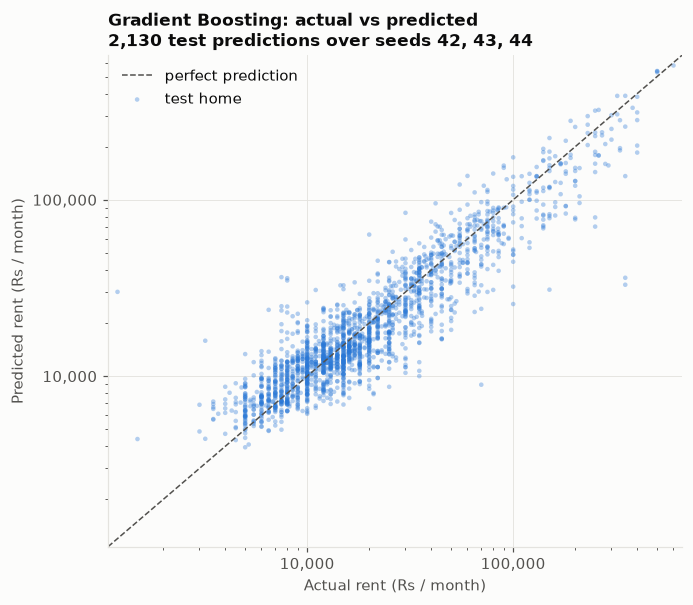

In [6]:
preds, breakdown, hist = save_final_diagnostics(final)
print(f'{len(preds):,} test predictions over seeds {sorted(preds.seed.unique())}')
breakdown.set_index(['Group', 'Value'])